Maria Navarro  
Spring 2024  
Advanced Healthcare Analytics and Data Mining
Smart ICU Bed Allocation System - SIBAS  
Predictive Analytics for Risk Profiling and Triaging Covid-19 Patients  

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import make_scorer, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

### **Data Processing**

In [2]:
raw_df = pd.read_csv('final_complete_data.csv')

C:\Users\mfncn\AppData\Local\Temp\ipykernel_13720\553678273.py:1: DtypeWarning: Columns (18,19,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('final_complete_data.csv')


In [3]:
# Remove unnecessary columns
columns_to_remove = ['Patient ID', 'AgeCode', 'SexCode', 'DX0', 'DX1', 'DX2', 'DX3', 'DX4', 'DX5', 'DX6', 'DX7', 'DX8', 'DX9', 'DX10', 'DX11', 'DX12', 'DX13', 'DX14', 'DX15', 'DX16', 'DX17', 'DX18', 'DX19', 'DX20', 'AgeBins']
df = raw_df.drop(columns=columns_to_remove)

In [4]:
df

,Mortality,GenderMale,Age_18_39,Age_40_49,Age_50_59,Age_60_69,Age_70_74,Age_75_99,Undefined_Undefined,CHEST_Chest_Wall_A,...,UROLG_GEN_Status_A,EYE___Malignant,BEHAV_Other_Nos_A,NEURO_Head_B,UROLG_GEN_Status2,UROLG_GEN_Status_B,UROLG_GEN_Screening,EYE___Macular_Degeneration,MSKLT_Status_A,GENRL_UNSP_Trauma
0,0,0,False,False,False,False,True,False,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,False,False,False,True,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,False,False,False,True,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,False,False,True,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,False,False,False,False,True,False,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370628,0,0,False,False,False,False,False,True,0,0,...,0,0,0,0,0,0,0,0,0,0
370629,1,0,False,False,False,False,False,True,0,0,...,0,0,1,0,0,0,0,0,0,0
370630,0,1,True,False,False,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
370631,0,1,False,False,False,False,False,True,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Checking number of nulls
null_counts = df.isnull().sum()
print(null_counts)

Mortality                     0
GenderMale                    0
Age_18_39                     0
Age_40_49                     0
Age_50_59                     0
                             ..
UROLG_GEN_Status_B            0
UROLG_GEN_Screening           0
EYE___Macular_Degeneration    0
MSKLT_Status_A                0
GENRL_UNSP_Trauma             0
Length: 228, dtype: int64


In [6]:
df['Mortality'].value_counts()

Mortality
0    349363
1     21270
Name: count, dtype: int64

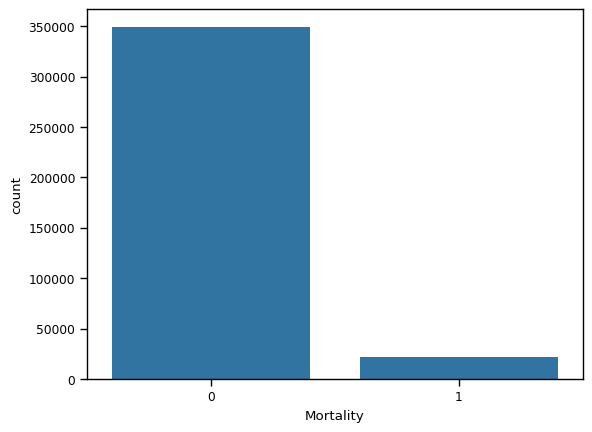

In [7]:
# Check class imbalance
sns.set_context('paper')
sns.countplot(data=df, x='Mortality')
plt.show()

# This is highly imbalanced

C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


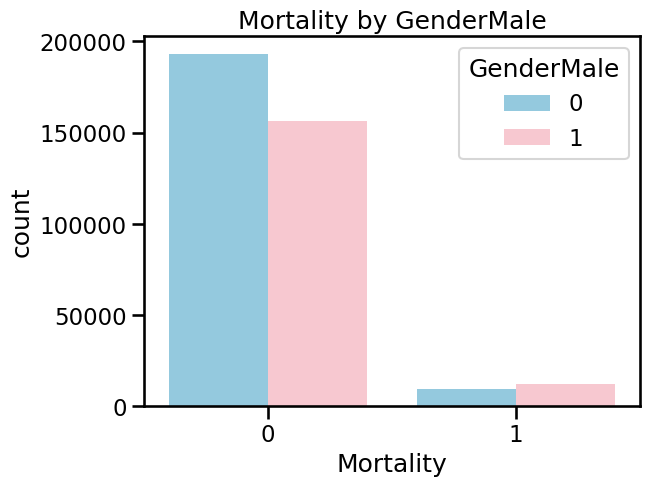

In [8]:
# Plot Mortality by Gender
sns.set_context('talk')
sns.countplot(data=df, x='Mortality', hue='GenderMale', palette=['skyblue', 'pink'])
plt.title('Mortality by GenderMale')
plt.show()

In [9]:
raw_df.AgeBins.unique()

array(['Age_70_74', 'Age_60_69', 'Age_50_59', 'Age_75_99', 'Age_40_49',
       'Age_18_39', 'RefUnder18'], dtype=object)

C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


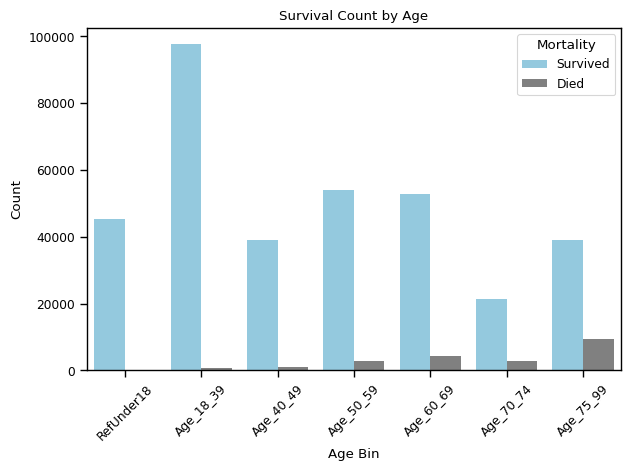

In [10]:
# Define the order of age bins
age_bin_order = ['RefUnder18','Age_18_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_74', 'Age_75_99']

# Plot the relationship between age bins and mortality
sns.set_context('paper')
sns.countplot(data=raw_df, x='AgeBins', hue='Mortality', palette=['skyblue', 'gray'], order=age_bin_order)
plt.xlabel('Age Bin')
plt.ylabel('Count')
plt.title('Survival Count by Age')
plt.legend(title='Mortality', labels=['Survived', 'Died'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

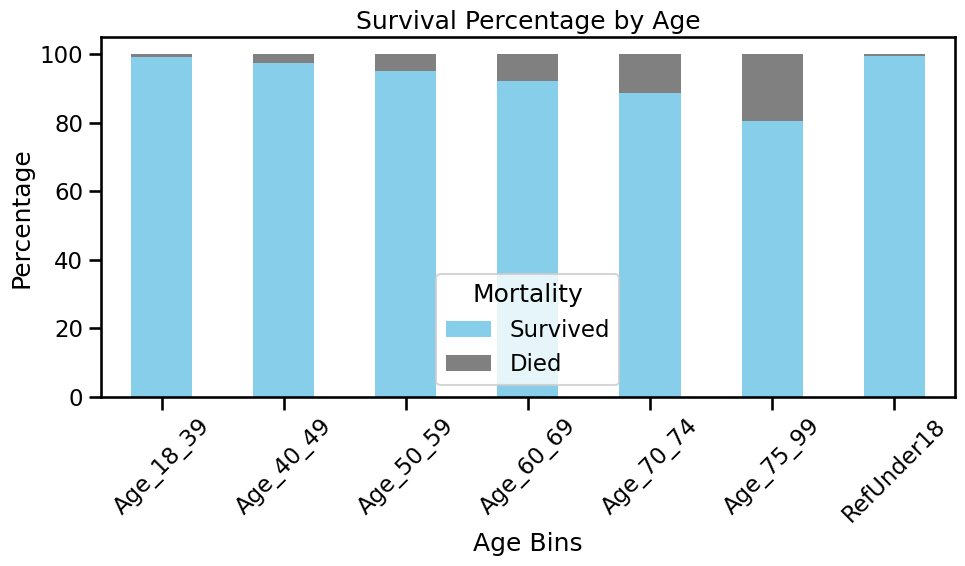

In [11]:
# Plotting Mortality Percentage by Age
# Calculate the counts of each combination of age bin and mortality
counts = raw_df.groupby(['AgeBins', 'Mortality']).size().unstack(fill_value=0)

# Normalize the counts to percentages
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar plot
sns.set_context('talk')
counts_percent.plot(kind='bar', stacked=True, color=['skyblue', 'gray'], figsize=(10, 6))

plt.xlabel('Age Bins')
plt.ylabel('Percentage')
plt.title('Survival Percentage by Age')
plt.xticks(rotation=45)
plt.legend(title='Mortality', labels=['Survived', 'Died'])
plt.tight_layout()
plt.show()

In [12]:
#Separate X from y
X = df.drop(columns=['Mortality'])  # Features
y = df['Mortality']  # Target variable

# Split the data into train and test sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Print the shapes of the train and test sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (277974, 227)
y_train shape: (277974,)
X_test shape: (92659, 227)
y_test shape: (92659,)


### **PCA**

In [13]:
# Scale features before applying PCA to ensure that each feature contributes equally to variance
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
n_components = 200
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

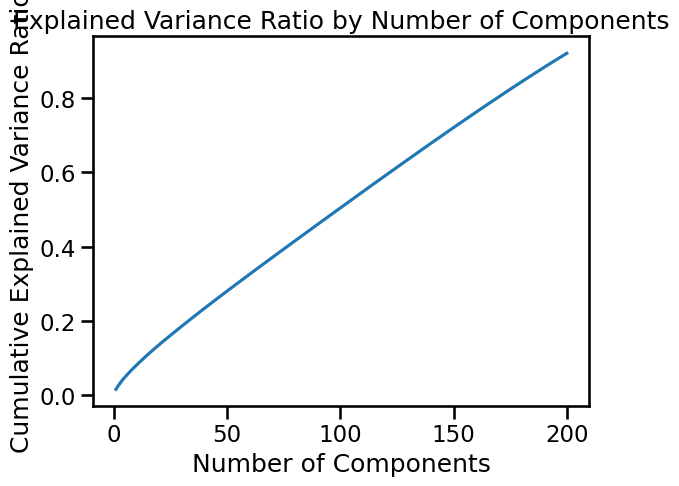

In [14]:
# Evaluate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot cumulative explained variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.plot(range(1, n_components + 1), cumulative_variance_ratio)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Components')
plt.show()

The plot of explained variance ratio by the number of components appears to be linear. This suggests that each additional principal component contributes roughly the same amount of variance to the total variance explained. Here's what it could mean:
- Linear Increase in Explained Variance: Each principal component captures a similar amount of variance in the data, resulting in a linear increase in the cumulative explained variance ratio as the number of components increases. This suggests that each additional component adds valuable information to the representation of the data.
- No Clear Dominant Components: In some cases, there may not be dominant components that explain a significantly larger proportion of variance compared to others. Instead, the variance is distributed relatively evenly across multiple components, leading to a linear trend in the explained variance ratio plot.

### **Modeling**

Training Logistic Regression

In [15]:
# Define model
lr = LogisticRegression()

# Define parameter grid
param_grid = {
    'penalty': [None, 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
}

# Conduct grid search with cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_lr.fit(X_train_scaled, y_train)

# Evaluate the best model
best_model_lr = grid_search_lr.best_estimator_
#y_pred = best_model.predict(X_test_scaled)

print("Best Parameters:", grid_search_lr.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'C': 1, 'penalty': 'l2'}


In [16]:
def evaluate_model_cv(model, X, y, cv):
    # Define scoring metrics
    scoring = {
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score)
    }
    
    # Perform cross-validation and calculate precision, recall, and F1-score
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    
    # Get the mean scores
    precision_mean = scores['test_precision'].mean()
    recall_mean = scores['test_recall'].mean()
    f1_mean = scores['test_f1'].mean()
    
    return precision_mean, recall_mean, f1_mean

In [17]:
precision_lr, recall_lr, f1_lr = evaluate_model_cv(best_model_lr, X_train_scaled, y_train, cv)
# Print the results
print("Precision (Mean):", precision_lr)
print("Recall (Mean):", recall_lr)
print("F1-score (Mean):", f1_lr)

Precision (Mean): 0.8962661473963494
Recall (Mean): 0.7664079866316835
F1-score (Mean): 0.8262313676606053


In [18]:
from sklearn.metrics import confusion_matrix

def calculate_confusion_matrix(model, X, y, cv):
    # Initialize an empty list to store confusion matrices for each fold
    conf_matrices = []

    # Perform cross-validation with Stratified K-Fold and calculate confusion matrix for each fold
    for train_index, test_index in cv.split(X, y):
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_test_fold)
        
        # Calculate confusion matrix for the current fold
        conf_matrices.append(confusion_matrix(y_test_fold, y_pred_fold))

    # Aggregate confusion matrices across all folds
    conf_matrix_sum = sum(conf_matrices)
    
    return conf_matrix_sum

In [19]:
conf_matrix_lr = calculate_confusion_matrix(best_model_lr, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_lr)

Aggregated Confusion Matrix:
[[260589   1417]
 [  3730  12238]]


Training a Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
# Define model
rf = RandomForestClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [100]#, 200, 300],
    #'max_depth': [None, 10, 20],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

best_model_rf = grid_search_rf.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (Random Forest):", grid_search_rf.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters (Random Forest): {'n_estimators': 100}


In [22]:
precision_rf, recall_rf, f1_rf = evaluate_model_cv(best_model_rf, X_train_scaled, y_train, cv)
# Print the results
print("Precision (Mean):", precision_rf)
print("Recall (Mean):", recall_rf)
print("F1-score (Mean):", f1_rf)

Precision (Mean): 0.872570117285678
Recall (Mean): 0.6256268359421959
F1-score (Mean): 0.7286975138763487


In [23]:
conf_matrix_rf = calculate_confusion_matrix(best_model_rf, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_rf)

Aggregated Confusion Matrix:
[[260541   1465]
 [  5977   9991]]


In [41]:
# Define model
rf = RandomForestClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [300]#, 200, 300],
    #'max_depth': [None, 10, 20],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search_rf_300 = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_rf_300.fit(X_train_scaled, y_train)

best_model_rf_300 = grid_search_rf_300.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (Random Forest):", grid_search_rf_300.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters (Random Forest): {'n_estimators': 300}


In [42]:
precision_rf_300, recall_rf_300, f1_rf_300 = evaluate_model_cv(best_model_rf_300, X_train_scaled, y_train, cv)
# Print the results
print("Precision (Mean):", precision_rf_300)
print("Recall (Mean):", recall_rf_300)
print("F1-score (Mean):", f1_rf_300)

Precision (Mean): 0.8745813748453293
Recall (Mean): 0.6292589593586942
F1-score (Mean): 0.731899268610019


In [43]:
conf_matrix_rf_300 = calculate_confusion_matrix(best_model_rf_300, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_rf_300)

Aggregated Confusion Matrix:
[[260562   1444]
 [  5897  10071]]


Training XGB Classifier

In [24]:
from xgboost import XGBClassifier

In [31]:
# Define model
xgb = XGBClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [100, 500, 1000],
    #'learning_rate': [0.01, 0.1, 1],
    'max_depth': [3, 5, 7],
}

# Perform grid search with cross-validation
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train)

best_model_xgb = grid_search_xgb.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (XGB Classifier):", grid_search_xgb.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters (XGB Classifier): {'max_depth': 3, 'n_estimators': 500}


In [32]:
precision_xgb, recall_xgb, f1_xgb = evaluate_model_cv(best_model_xgb, X_train_scaled, y_train, cv)
# Print the results
print("Precision (Mean):", precision_xgb)
print("Recall (Mean):", recall_xgb)
print("F1-score (Mean):", f1_xgb)

Precision (Mean): 0.8843093715582245
Recall (Mean): 0.7677860010381978
F1-score (Mean): 0.8219146070188119


In [33]:
conf_matrix_xgb = calculate_confusion_matrix(best_model_xgb, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_xgb)

Aggregated Confusion Matrix:
[[260401   1605]
 [  3708  12260]]


Training Gradient Boosting Classifier

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

In [38]:
# Define model
gb = GradientBoostingClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [100]#, # tried 1000 but too slow
    #'learning_rate': [0.01, 0.1, 1],
    #'max_depth': [3, 5, 7],
}

# Perform grid search with cross-validation
grid_search_gb = GridSearchCV(estimator=gb, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_gb.fit(X_train_scaled, y_train)

best_model_gb = grid_search_gb.best_estimator_
#y_pred_gb = best_model_gb.predict(X_test_scaled)

print("Best Parameters (Gradient Boosting Classifier):", grid_search_gb.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters (Gradient Boosting Classifier): {'n_estimators': 100}


In [39]:
precision_gb, recall_gb, f1_gb = evaluate_model_cv(best_model_gb, X_train_scaled, y_train, cv)
# Print the results
print("Precision (Mean):", precision_gb)
print("Recall (Mean):", recall_gb)
print("F1-score (Mean):", f1_gb)

Precision (Mean): 0.8802096729408803
Recall (Mean): 0.6776682556021792
F1-score (Mean): 0.7657256636252198


In [40]:
conf_matrix_gb = calculate_confusion_matrix(best_model_gb, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_gb)

Aggregated Confusion Matrix:
[[260532   1474]
 [  5147  10821]]


In [46]:
# Create dictionary to store the metrics for each model
metrics_dict = {
    'Model':['Logistic Regression', 'Random Forest', 'Random Forest v2', 'XGBoost', 'Gradient Boosting'],
    'Precision': [precision_lr, precision_rf, precision_rf_300, precision_xgb, precision_gb],
    'Recall': [recall_lr, recall_rf, recall_rf_300, recall_xgb, recall_gb],
    'F1-score': [f1_lr, f1_rf, f1_rf_300, f1_xgb, f1_gb]
}

# Convert dictionary to dataframe
metrics_df = pd.DataFrame(metrics_dict)

# Print dataframe
print(metrics_df)

                 Model  Precision    Recall  F1-score
0  Logistic Regression   0.896266  0.766408  0.826231
1        Random Forest   0.872570  0.625627  0.728698
2     Random Forest v2   0.874581  0.629259  0.731899
3              XGBoost   0.884309  0.767786  0.821915
4    Gradient Boosting   0.880210  0.677668  0.765726


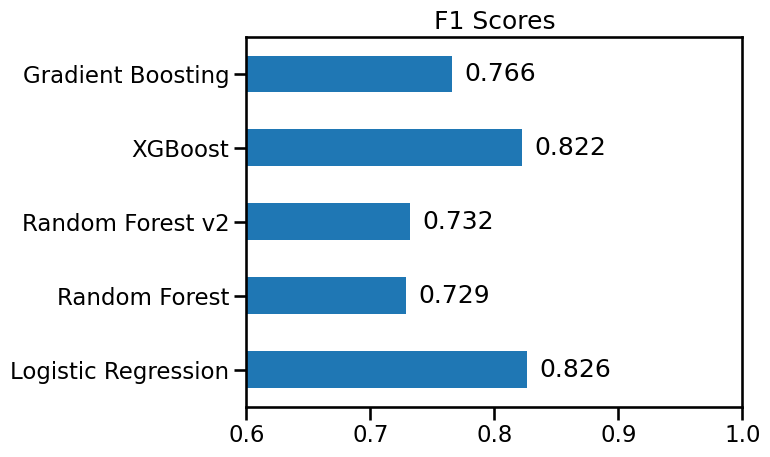

In [84]:
sns.set_context('talk')

# Plot the bar chart
ax = metrics_df['F1-score'].plot(kind='barh')

plt.title('F1 Scores')

# Set y-axis limits
plt.xlim(0.6, 1.0)

# Add value annotations for each bar
for i, v in enumerate(metrics_df['F1-score']):
    ax.text(v + 0.01, i, f'{v:.3f}', ha='left', va='center')

# Set x-axis labels
ax.set_yticklabels(metrics_df.Model)


plt.show()

### **Best Model**

In [ ]:
# Get predicted probabilities for the positive class (mortality) as risk scores
# This will give you an array of predicted probabilities, where each element represents the probability of the positive class for the corresponding instance
#predicted_probabilities_train = best_model_lr.predict_proba(X_train_scaled)[:, 1]

In [52]:
# Since we used cross-validation during the grid search process to determine the best model for logistic regression, we can obtain the predicted probabilities for each fold during CV and 
#then aggregate them to get an overall estimation of the probabilities

from sklearn.model_selection import cross_val_predict

# Perform cv to obtain predicted probabilities for each fold
predicted_probabilities_train = cross_val_predict(best_model_lr, X_train_scaled, y_train, cv=cv, method='predict_proba')

# Extract the probabilities for the positive class (mortality)
predicted_probabilities_train_positive_class = predicted_probabilities_train[:, 1]

# Display the predicted probabilities
print(predicted_probabilities_train_positive_class)


[7.53789631e-04 7.44584141e-03 3.93517953e-03 ... 9.85278323e-01
 5.95040699e-04 9.48777176e-04]


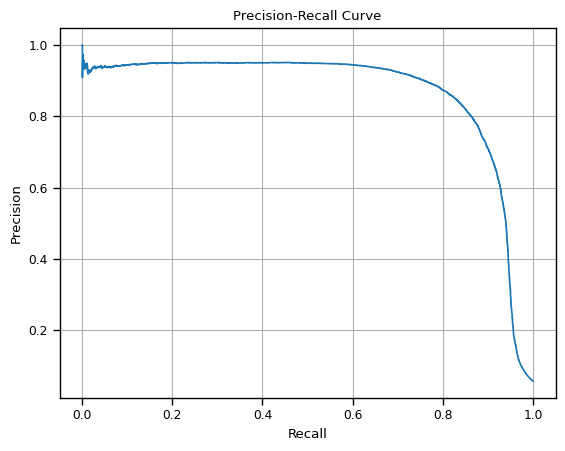

In [57]:
# Plot precision-recall curves to visualize how precision and recall change as the threshold for classifying positive instances changes

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, predicted_probabilities_train_positive_class)

# Plot precision-recall curve
sns.set_context('paper')
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

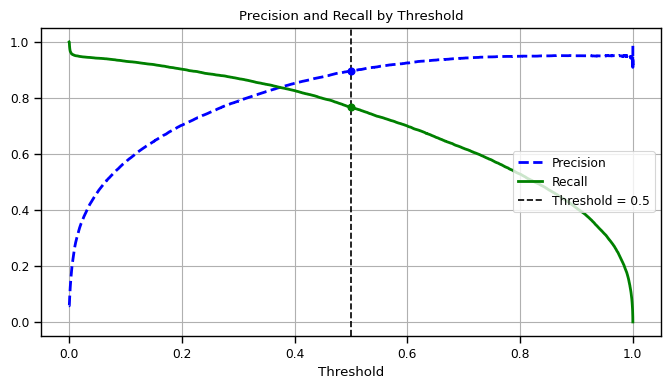

In [66]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#plt.vlines(thresholds, 0, 0.5, "k", "dotted", label="threshold")

# Plot vertical line for threshold
plt.axvline(x=0.5, color="k", linestyle="--", label="Threshold = 0.5")

# Plot markers for threshold point
idx = (thresholds >= 0.5).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.grid()
plt.title('Precision and Recall by Threshold')
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.show()

### **Making Predictions on Test Set**

Logistic Regression

Logistic Regression Metrics:
Precision: 0.8965440850686752
Recall: 0.7632968691059977
F1-score: 0.8245721271393643


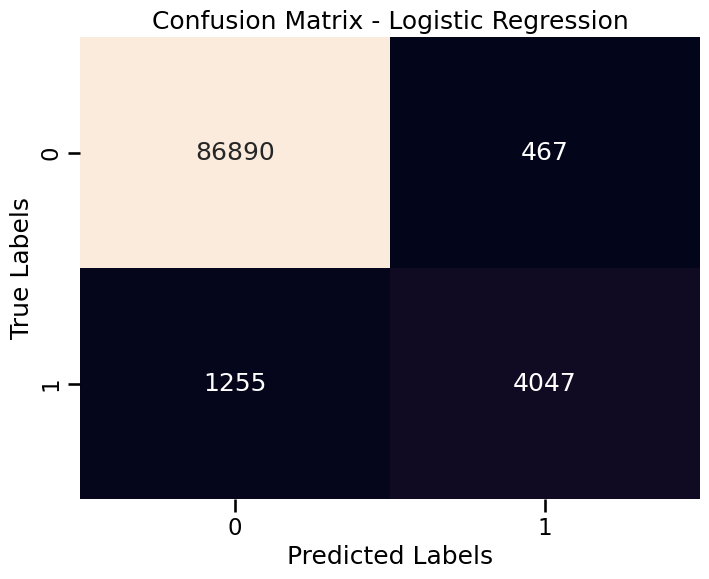

In [88]:
# Make predictions using Logistic Regression model
y_pred_lr_test = best_model_lr.predict(X_test_scaled)

# Calculate precision, recall, and F1-score
precision_lr_test = precision_score(y_test, y_pred_lr_test)
recall_lr_test = recall_score(y_test, y_pred_lr_test)
f1_lr_test = f1_score(y_test, y_pred_lr_test)

# Print precision, recall, and F1-score
print("Logistic Regression Metrics:")
print("Precision:", precision_lr_test)
print("Recall:", recall_lr_test)
print("F1-score:", f1_lr_test)

# Plot confusion matrix
sns.set_context('talk')
plt.figure(figsize=(8, 6))
conf_matrix_lr_test = confusion_matrix(y_test, y_pred_lr_test)
sns.heatmap(conf_matrix_lr_test, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

XGBoost Classifier

XGBoost Metrics:
Precision: 0.8851674641148325
Recall: 0.7676348547717843
F1-score: 0.8222222222222222


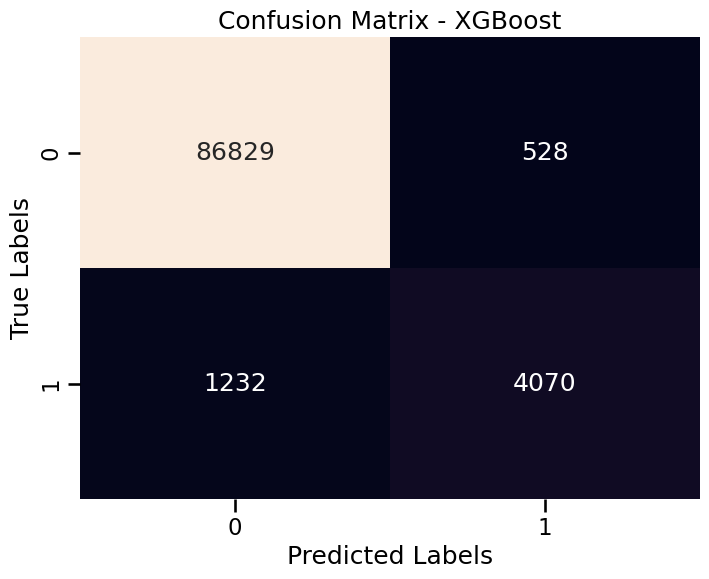

In [89]:
# Make predictions using XGBoost model
y_pred_xgb_test = best_model_xgb.predict(X_test_scaled)

# Calculate precision, recall, and F1-score
precision_xgb_test = precision_score(y_test, y_pred_xgb_test)
recall_xgb_test = recall_score(y_test, y_pred_xgb_test)
f1_xgb_test = f1_score(y_test, y_pred_xgb_test)

# Print precision, recall, and F1-score
print("XGBoost Metrics:")
print("Precision:", precision_xgb_test)
print("Recall:", recall_xgb_test)
print("F1-score:", f1_xgb_test)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
conf_matrix_xgb_test = confusion_matrix(y_test, y_pred_xgb_test)
sns.heatmap(conf_matrix_xgb_test, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [90]:
# Generate predicted probabilities for the positive class (class 1) on the test set
predicted_probabilities_test = best_model_lr.predict_proba(X_test_scaled)

# Extract probabilities for the positive class (class 1)
predicted_probabilities_test_positive_class = predicted_probabilities_test[:, 1]

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve

In [110]:
# Calculate precision and recall
precisions_test, recalls_test, thresholds_test = precision_recall_curve(y_test, predicted_probabilities_test_positive_class)

# Create an interactive precision-recall curve
fig = go.Figure()

# Add precision-recall curve
#fig.add_trace(go.Scatter(x=recalls_test, y=precisions_test, mode='lines', name='Precision-Recall Curve'))

fig.add_trace(go.Scatter(x=recalls_test, y=precisions_test, mode='lines',
                         hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<br>Threshold: %{text:.2f}',
                         text=thresholds_test, name='Precision-Recall Curve'))

# Update layout
fig.update_layout(title='Precision-Recall Curve - Test Set',
                  xaxis_title='Recall',
                  yaxis_title='Precision',
                  hovermode='closest',
                  width=800,
                  height=700,
                  xaxis=dict(
        title_font=dict(size=20),  # Set the font size for x-axis label
        tickfont=dict(size=20)  # Set the font size for x-axis tick label
    ),
    yaxis=dict(
        title_font=dict(size=20),  # Set the font size for y-axis label
        tickfont=dict(size=20)  # Set the font size for y-axis tick labels
    ))

# Show plot
fig.show()

Feature Importance

We can analyze the importance of features in a logistic regression model by examining the coefficients associated with each feature. Since logistic regression is a linear model, the magnitude of the coefficients provides information about the importance of each feature in predicting the target variable.  

This plot will show you the relative importance of each feature in the logistic regression model. Features with larger absolute coefficient values are considered more important in predicting the target variable. 

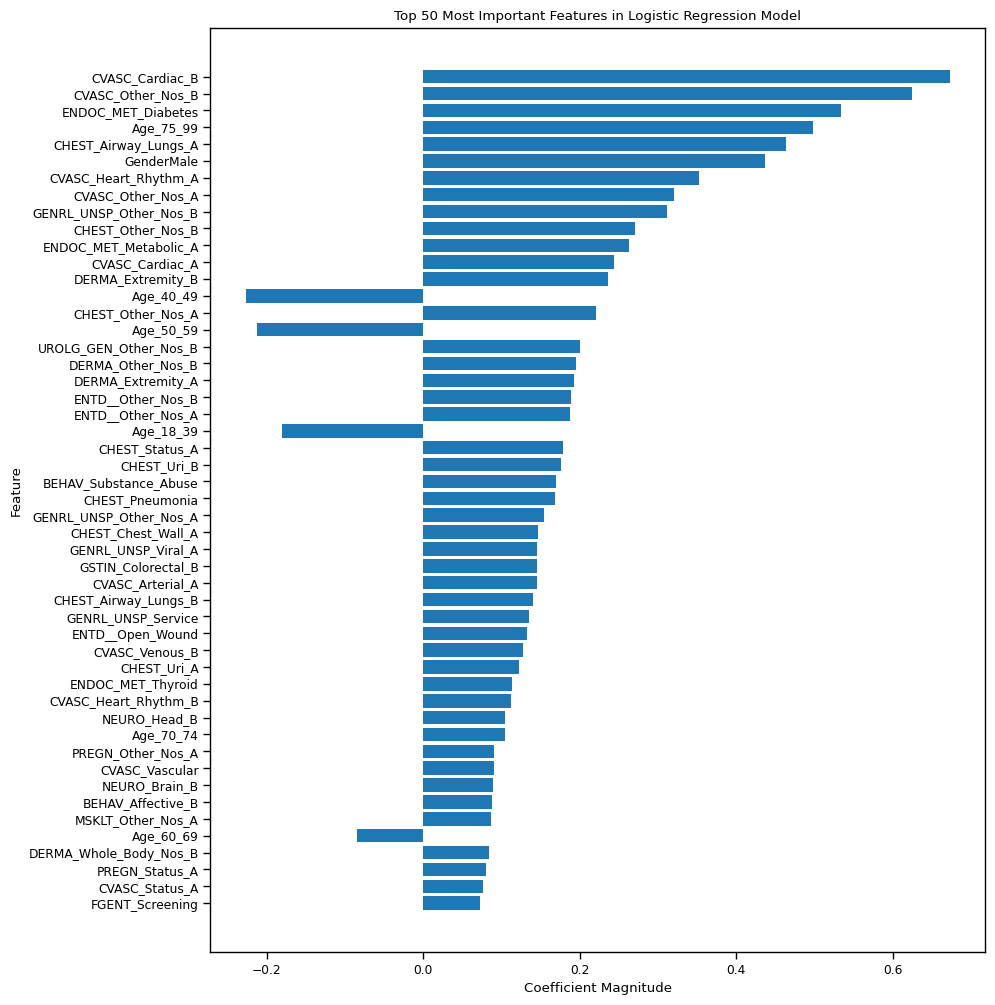

In [113]:
# Get the coefficients and feature names
coefficients = best_model_lr.coef_[0]
feature_names = X_train.columns

# Sort coefficients and feature names by absolute coefficient value
indices = np.argsort(np.abs(coefficients))
sorted_coefficients = coefficients[indices]
sorted_feature_names = feature_names[indices]

# Select top 50 most important features
top_50_coefficients = sorted_coefficients[-50:]
top_50_feature_names = sorted_feature_names[-50:]

# Plot top 50 most important features
sns.set_context('paper')
plt.figure(figsize=(10, 12))
plt.barh(range(len(top_50_feature_names)), top_50_coefficients, align='center')
plt.yticks(range(len(top_50_feature_names)), top_50_feature_names)
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Top 50 Most Important Features in Logistic Regression Model')
plt.show()